In [1]:
# =========================
# 1. IMPORTS
# =========================
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
base_path = r"C:\Users\LapTechnology\PyCharmMiscProject\mit-bih-noise-stress-test-database-1.0.0\mit-bih-noise-stress-test-database-1.0.0"

# ECG records used as clean signals

records = [
    "118e00", "118e06", "118e12",
    "119e00", "119e06", "119e12"
]
# Noise classes

noise_types = ["bw", "em", "ma"]

In [3]:
X = [] # ECG segments
y = []   # Labels

# Window size for each ECG segment
window = 300


In [4]:
# 50% overlap between segments

step = window // 2


# =========================
# Load Clean ECG Signals
# =========================

for rec in records:
    # Read ECG record

    record = wfdb.rdrecord(base_path + "\\" + rec)
    # Take first ECG channel only

    signal = record.p_signal[:, 0]

    for i in range(0, len(signal) - window, step):
    # Extract segment

        segment = signal[i:i+window]
        X.append(segment)
        y.append("clean")

In [5]:
# =========================
# Load Noise Signals
# =========================

for noise in noise_types:
    # Read noise record

    record = wfdb.rdrecord(base_path + "\\" + noise)
    # Take first channel

    signal = record.p_signal[:, 0]
    # Split noise signal into segments

    for i in range(0, len(signal) - window, step):
        X.append(signal[i:i+window])
        y.append(noise)

In [6]:
# =========================
# Convert Lists to Arrays
# =========================

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (38988, 300)


In [7]:
# =========================
# Preprocessing
# =========================

# Convert datatype to float32

X = X.astype(np.float32)

for i in range(len(X)):

    seg = X[i]

    # 1. Remove DC shift (center signal around zero)
    seg = seg - np.mean(seg)

    # 2. Normalize amplitude
    seg = seg / (np.std(seg) + 1e-8)

    # 3. Smooth noise slightly (optional but strong)
    seg = np.convolve(seg, np.ones(5)/5, mode='same')

    X[i] = seg

In [8]:
# =========================
# Encode Labels
# =========================
# Convert string labels into numeric labels


le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['bw' 'clean' 'em' 'ma']


In [23]:
# =========================
# Reshape Data for CNN
# =========================
# Shape becomes:
# (samples, time_steps, channels)


X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape)

(38988, 300, 1)


In [10]:
# =========================
# Split Dataset
# =========================


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
# =========================
# Compute Class Weights
# =========================
# Helps balance imbalanced classes


weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), weights))

print(class_weight_dict)

{np.int64(0): np.float64(2.249711482977496), np.int64(1): np.float64(0.3750060116385322), np.int64(2): np.float64(2.249711482977496), np.int64(3): np.float64(2.2503607503607506)}


In [12]:
# =========================
# Build CNN Model
# =========================
model = models.Sequential()

# ----- First Convolution Block -----
model.add(layers.Conv1D(
    32,
    5,
    padding='same',
    input_shape=(window, 1)
))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling1D(2))

# ----- Second Convolution Block -----
model.add(layers.Conv1D(64, 5, padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling1D(2))

# ----- Third Convolution Block -----
model.add(layers.Conv1D(128, 3, padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling1D(2))

# Convert feature maps into feature vector
model.add(layers.GlobalAveragePooling1D())

# Fully connected layer
model.add(layers.Dense(64, activation='relu'))

# Dropout to reduce overfitting
model.add(layers.Dropout(0.5))

# Output layer with softmax activation
model.add(layers.Dense(
    len(np.unique(y)),
    activation='softmax'
))

C:\Users\LapTechnology\PyCharmMiscProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# =========================
# Compile Model
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# =========================
# Early Stopping Callback
# =========================
# Stop training if validation loss
# does not improve


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

In [15]:
# =========================
# Learning Rate Scheduler
# =========================
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce learning rate when validation loss stops improving
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [16]:
# =========================
#  Train Model
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_reducer]
)

Epoch 1/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7979 - loss: 0.3991 - val_accuracy: 0.7874 - val_loss: 0.5719 - learning_rate: 0.0010
Epoch 2/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8650 - loss: 0.2351 - val_accuracy: 0.7324 - val_loss: 0.7726 - learning_rate: 0.0010
Epoch 3/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8826 - loss: 0.2047 - val_accuracy: 0.9229 - val_loss: 0.1789 - learning_rate: 0.0010
Epoch 4/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8984 - loss: 0.1804 - val_accuracy: 0.9078 - val_loss: 0.2274 - learning_rate: 0.0010
Epoch 5/25
485/488 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9020 - loss: 0.1727
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
488/488 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8996 - loss: 0.1785 - val_accuracy: 0.7544 - val_loss: 0.7293 - learning_rate: 0.0010
Epoch 6/25
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9137 - loss

In [17]:
# =========================
#  Evaluate Model
# =========================
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9391 - loss: 0.1481
Test Accuracy: 0.9390869736671448
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

          bw       0.96      1.00      0.98       866
       clean       0.99      0.92      0.96      5199
          em       0.68      0.95      0.79       866
          ma       0.98      0.98      0.98       867

    accuracy                           0.94      7798
   macro avg       0.90      0.96      0.93      7798
weighted avg       0.95      0.94      0.94      7798



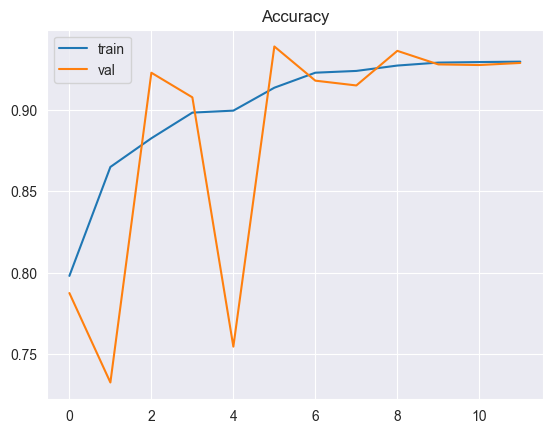

In [18]:
# =========================
# Plot Accuracy Curves
# =========================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.show()

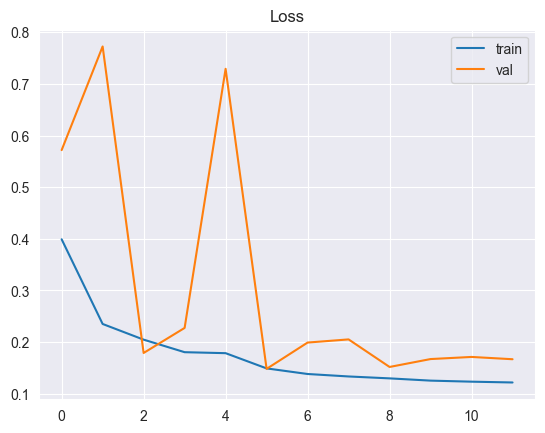

In [19]:
# =========================
# Plot Loss Curves
# =========================

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()
plt.show()

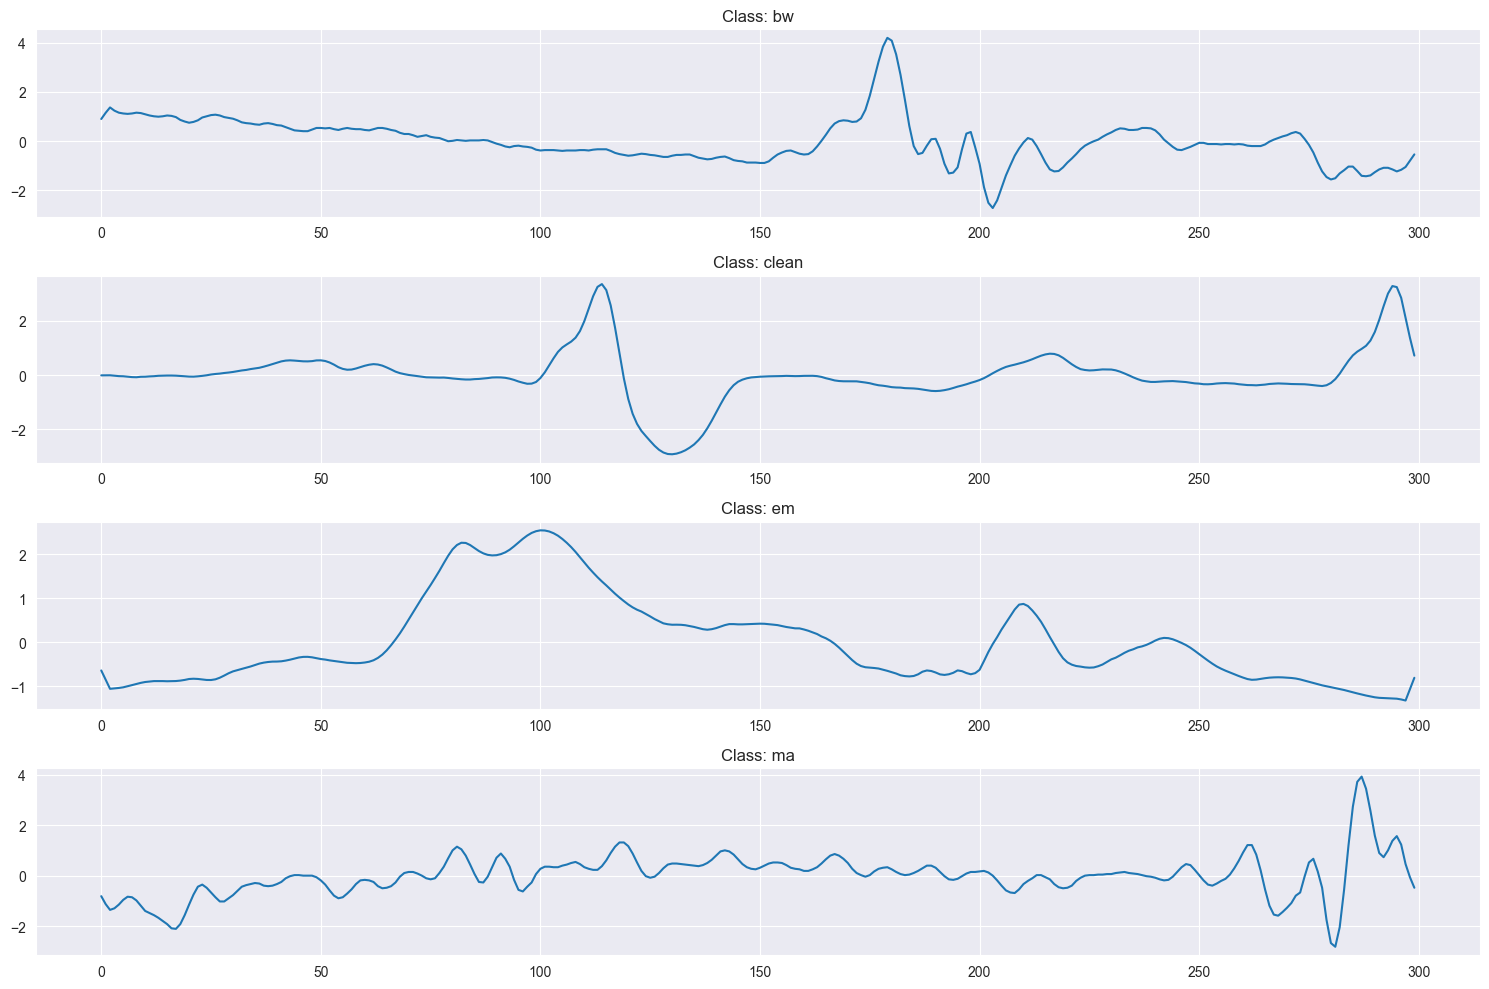

In [20]:
# =========================
# Visualize ECG Samples
# =========================


classes = np.unique(le.inverse_transform(y_test))
plt.figure(figsize=(15, 10))

for i, cls_name in enumerate(classes):
    idx = np.where(le.inverse_transform(y_test) == cls_name)[0][0]
    plt.subplot(len(classes), 1, i+1)
    plt.plot(X_test[idx].flatten())
    plt.title(f"Class: {cls_name}")
    plt.grid(True)

plt.tight_layout()
plt.show()

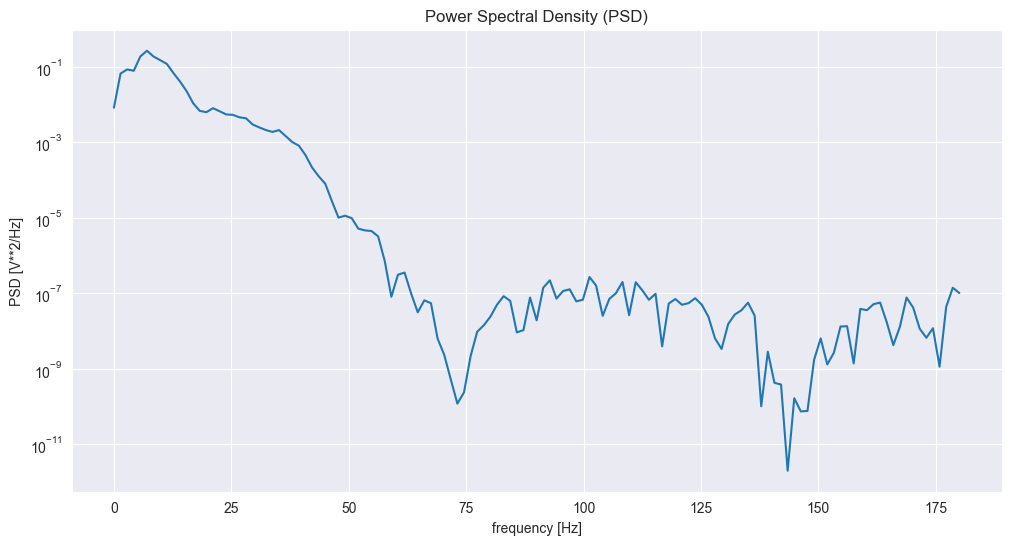

In [21]:
# =========================
# Power Spectral Density (PSD)
# =========================


from scipy import signal as scipy_signal

plt.figure(figsize=(12, 6))
f, Pxx_den = scipy_signal.welch(X_test[0].flatten(), fs=360)
plt.semilogy(f, Pxx_den)
plt.title('Power Spectral Density (PSD)')
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

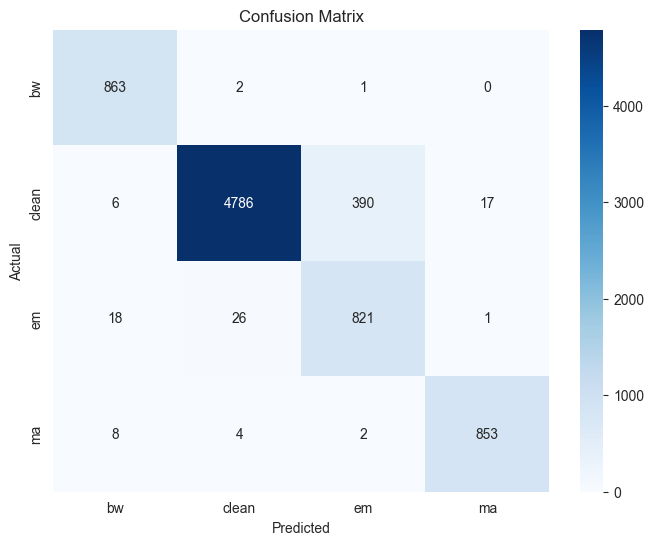

In [22]:
# =========================
# Confusion Matrix
# =========================


from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()